In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving names.txt to names.txt


In [ ]:
words=open('names.txt','r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(1):


  ix = torch.randint(0, Xtr.shape[0], (32,))


  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  for p in parameters:
    p.grad = None
  loss.backward()


  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad


  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())
print(loss.item())

3.1581716537475586


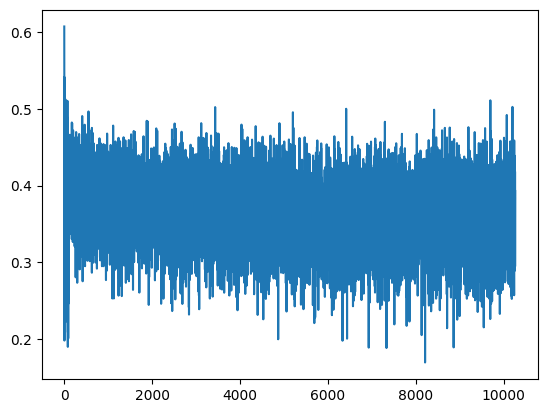

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1629, grad_fn=<NllLossBackward0>)

In [ ]:
# After randomizing the parameters and setting epochs to 20k observed a loss of 2.16 on vadilation set.

In [ ]:
#write now we are initializing parameters with Generator function randomly, but when we want a uniform loss
#For uniform loss the, the probability should be uniform
# For making probability uniform if we equat the weigths to approx 0 , such that the output of each of 27 chars probability is same through NN
#We would get a uniform probability corresponding to each char.

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
#the loss observed after setting W2 to approximately 0 was 3.15 which similar to 3.3
#As W2 was not totally 0, there was slight deviation in loss.

In [ ]:
# Trying implementation from paper; the paper claims that :"Neural language models can benefit from longer contexts better than traditional n-grams because similar words share embeddings."
#Hence will try to increase the block size and understand to what extent reduction in loss could be observed.

0.4458782374858856 1
0.6138795018196106 2
0.775574266910553 3
0.962662398815155 4
0.7974786162376404 5
0.7272927165031433 6
0.7453540563583374 7
0.5467707514762878 8
0.6269113421440125 9
0.5913762450218201 10
0.681626558303833 11
0.5365480780601501 12
0.5697044730186462 13
0.5308395624160767 14
0.6251798868179321 15
0.5865452289581299 16
0.5201903581619263 17
0.44858381152153015 18
0.560038149356842 19
0.46329110860824585 20
0.5965307354927063 21
0.5749282836914062 22
0.5760482549667358 23
0.6712091565132141 24
0.7578566074371338 25
0.5044159889221191 26
0.5139815211296082 27
0.854400634765625 28
0.5504836440086365 29
0.48300641775131226 30
0.4658820927143097 31
0.4734886586666107 32
0.6043096780776978 33
0.5783150792121887 34
0.4672493040561676 35
0.6031872034072876 36
0.5376058220863342 37
0.6257875561714172 38
0.4890177845954895 39
0.5153259634971619 40
0.5589907765388489 41
0.5054119229316711 42
0.7236182689666748 43
0.6117841005325317 44
0.6067789196968079 45
0.6718283295631409 46

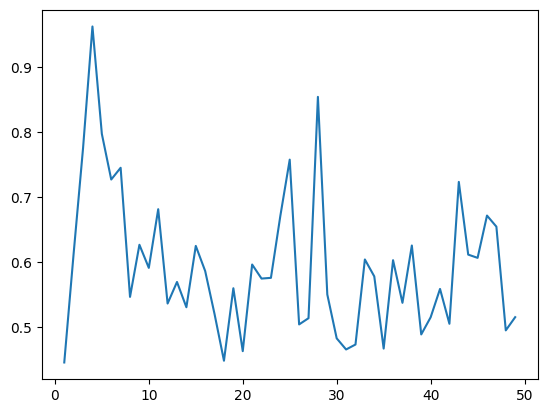

In [ ]:
block=[]
lossb=[]
import random
for j in range(1,50,1):

 block_size = j

 def build_dataset(words):
   X, Y = [], []
   for w in words:


    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

   X = torch.tensor(X)
   Y = torch.tensor(Y)
   return X, Y


 random.seed(42)
 random.shuffle(words)
 n1 = int(0.8*len(words))
 n2 = int(0.9*len(words))

 Xtr, Ytr = build_dataset(words[:n1])
 Xdev, Ydev = build_dataset(words[n1:n2])
 Xte, Yte = build_dataset(words[n2:])
 g = torch.Generator().manual_seed(2147483647)
 C = torch.randn((27, 10), generator=g)
 W1 = torch.randn((j*10, 200), generator=g)
 b1 = torch.randn(200, generator=g)
 W2 = torch.randn((200, 27), generator=g)
 b2 = torch.randn(27, generator=g)
 parameters = [C, W1, b1, W2, b2]
 for p in parameters:
  p.requires_grad = True
 for i in range(300):


  ix = torch.randint(0, Xtr.shape[0], (32,))


  emb = C[Xtr[ix]] # (32, j, 2)
  h = torch.tanh(emb.view(-1, j*10) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  for p in parameters:
    p.grad = None
  loss.backward()


  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad


  #lri.append(lre[i])
#stepi.append(i)
 lossb.append(loss.log10().item())
 print(loss.log10().item(),j)
 block.append(j)
plt.plot(block,lossb)

In [ ]:
# on an average the loss reduces with increasing the block size, though there is a question upon is there a need to increase the block
# after reaching somewhat minima as further increasing block size doesn't contribute much to reduction in loss while
#increases the computation requirement
# Optimization of this trade off needs to be taken care of.

In [ ]:
#part 2

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving names.txt to names.txt


In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
block_size = 3

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0 #(5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.0
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
W1v=[]
W2v=[]
b2v=[]
W1g=[]
W2g=[]
b2g=[]
stepi=[]
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    W1v.append(W1.mean().item())
    W2v.append(W2.mean().item())
    b2v.append(b2.mean().item())

    W1g.append(W1.grad.abs().mean().item())
    W2g.append(W2.grad.abs().mean().item())
    b2g.append(b2.grad.abs().mean().item())
    stepi.append(i)
  lossi.append(loss.log10().item())


      0/ 200000: nan
  10000/ 200000: nan
  20000/ 200000: nan
  30000/ 200000: nan
  40000/ 200000: nan
  50000/ 200000: nan
  60000/ 200000: nan
  70000/ 200000: nan
  80000/ 200000: nan
  90000/ 200000: nan
 100000/ 200000: nan
 110000/ 200000: nan
 120000/ 200000: nan
 130000/ 200000: nan
 140000/ 200000: nan
 150000/ 200000: nan
 160000/ 200000: nan
 170000/ 200000: nan
 180000/ 200000: nan
 190000/ 200000: nan


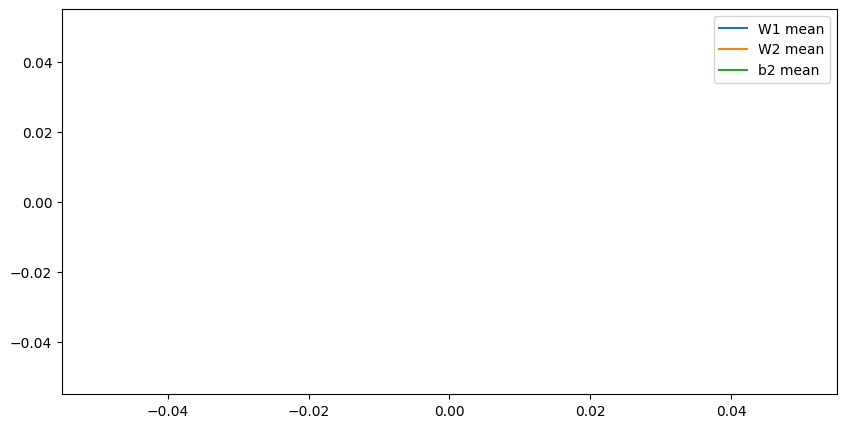

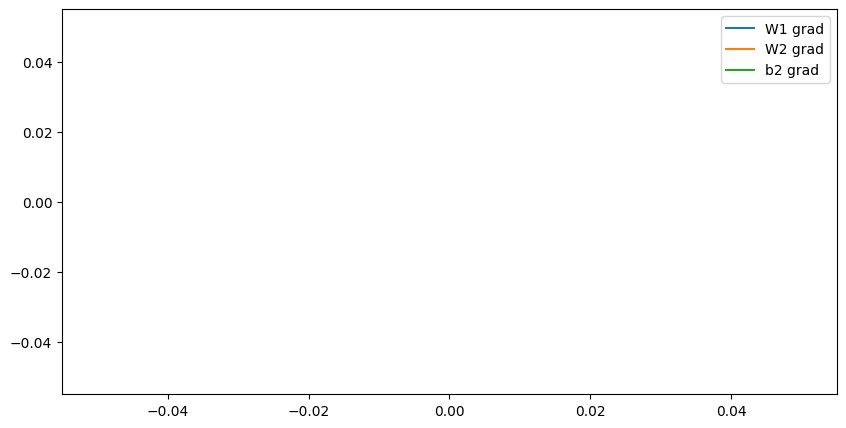

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(stepi, W1v, label="W1 mean")
plt.plot(stepi, W2v, label="W2 mean")
plt.plot(stepi, b2v, label="b2 mean")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(stepi, W1g, label="W1 grad")
plt.plot(stepi, W2g, label="W2 grad")
plt.plot(stepi, b2g, label="b2 grad")
plt.legend()
plt.show()

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674147605895996
val 2.1056840419769287


In [ ]:
# The hpreat becomes Nan when weigths and baises are set to 0 and hence the loss after every epoch is Nan.
# The network is not able to learn as because of setting everything to 0, each and every example is learned in same way.
# Hence every example looks identical because of which gradients also vanish
# As graidents vanish weights and baises have no update and hence left as 0 through out.
# Thus, we can claim that network is not able to learn through the process and remains nullified.
# While as karpathy says, it learns partially I think just the batchnorm bais is able to learn while the grads for actual layer weigths still remain 0.


In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *(5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1
  scale = bngain / bnstd_running
  W1_folded = W1 * scale
  b1_folded = bnbias - scale * bnmean_running
  hpreact = embcat @ W1_folded + b1_folded
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


In [ ]:
#the final loss observed is quite similar to one observed from the batchnorm implementation
# Indirectly the same process is followed to get the whole training and validation loss just other than again making it gaussian wth mean and std, folded weigths and bais is used.